# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Imam Dza Qhoir
- **Email:** qhosans@gmail.com
- **ID Dicoding:** shin_zeleo

## Menentukan Pertanyaan Bisnis

1. Bagaimana perbandingan jumlah penyewaan sepeda antar musim pada tahun 2012?
2. Sejauh mana kondisi cuaca memengaruhi jumlah penyewaan sepeda harian selama tahun 2012?
3. Bagaimana perbandingan tren jam sibuk penyewaan sepeda antara hari kerja dan hari libur dalam 12 bulan terakhir?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv('data/day.csv')
hour_df = pd.read_csv('data/hour.csv')

In [3]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
print(f"Shape day_df: {day_df.shape}")
print(f"Shape hour_df: {hour_df.shape}")

Shape day_df: (731, 16)
Shape hour_df: (17379, 17)


**Insight:**
- Dataset ini terbagi menjadi dua, yaitu data harian (731 baris) dan per jam (17.379 baris), sehingga memberikan perspektif waktu yang lebih komprehensif terkait penggunaan sepeda.
- Data di dalamnya mencakup berbagai faktor penentu seperti musim, cuaca, suhu, dan total penyewaan, yang sangat mendukung untuk proses analisis pola penggunaan.
- Kombinasi variabel waktu dan kondisi lingkungan menjadikan dataset ini sangat memadai untuk mendalami faktor-faktor apa saja yang memengaruhi tingkat penyewaan.

### Assessing Data

#### Assessing `day_df`

In [6]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [7]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [8]:
print("Jumlah missing value day_df:")
display(day_df.isnull().sum())

print(f"\nJumlah data duplikat day_df: {day_df.duplicated().sum()}")

Jumlah missing value day_df:


instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


Jumlah data duplikat day_df: 0


#### Assessing `hour_df`

In [9]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [10]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [11]:
print("Jumlah missing value hour_df:")
display(hour_df.isnull().sum())

print(f"\nJumlah data duplikat hour_df: {hour_df.duplicated().sum()}")

Jumlah missing value hour_df:


instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


Jumlah data duplikat hour_df: 0


In [12]:
print("Tipe data hour_df:")
display(hour_df.dtypes)

Tipe data hour_df:


instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

**Insight:**
- Tidak ditemukan missing value maupun data duplikat pada kedua dataset (`day_df` dan `hour_df`), sehingga data dapat langsung digunakan untuk analisis tanpa proses pembersihan yang kompleks.
- Dataset harian memiliki 731 entri dengan 16 kolom, sedangkan dataset per jam memiliki 17.379 entri dengan 17 kolom (termasuk kolom `hr` untuk jam).
- Beberapa variabel seperti `season`, `weekday`, dan `weathersit` direpresentasikan dalam bentuk angka, namun sebenarnya bersifat kategorikal.
- Rata-rata jumlah penyewaan sepeda per hari berada di kisaran 4.500, dengan nilai maksimum mencapai lebih dari 8.000.
- Variabel seperti suhu (`temp`) dan kelembapan (`hum`) memiliki rentang nilai yang cukup bervariasi, sehingga berpotensi memengaruhi jumlah penyewaan sepeda.

### Cleaning Data

In [13]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [14]:
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow'
}

day_df['season'] = day_df['season'].map(season_map)
day_df['weathersit'] = day_df['weathersit'].map(weather_map)

hour_df['season'] = hour_df['season'].map(season_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)

In [15]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [16]:
day_df[['season', 'weathersit']].head()

,season,weathersit
0,Spring,Mist
1,Spring,Mist
2,Spring,Clear
3,Spring,Clear
4,Spring,Clear


**Insight:**
- Kolom tanggal (`dteday`) telah dikonversi ke format datetime sehingga memudahkan analisis berbasis waktu.
- Variabel `season` dan `weathersit` pada kedua dataset (`day_df` dan `hour_df`) telah diubah menjadi label deskriptif.
- Tidak ditemukan missing value maupun data duplikat, sehingga tidak diperlukan proses pembersihan data yang kompleks.
- Secara keseluruhan, dataset sudah dalam kondisi rapi dan siap digunakan untuk tahap eksplorasi lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore Data Harian

In [17]:
day_df.groupby('season')['cnt'].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
Fall,188.0,5644.303191,1459.800381,1115.0,4586.5,5353.5,6929.25,8714.0
Spring,181.0,2604.132597,1399.942119,431.0,1538.0,2209.0,3456.00,7836.0
Summer,184.0,4992.331522,1695.977235,795.0,4003.0,4941.5,6377.00,8362.0
Winter,178.0,4728.162921,1699.615261,22.0,3615.5,4634.5,5624.50,8555.0


In [18]:
day_df.groupby('weathersit')['cnt'].describe()

,count,mean,std,min,25%,50%,75%,max
weathersit,,,,,,,,
Clear,463.0,4876.786177,1879.483989,431.0,3636.5,4844.0,6458.5,8714.0
Light Snow/Rain,21.0,1803.285714,1240.284449,22.0,705.0,1817.0,2424.0,4639.0
Mist,247.0,4035.862348,1809.109918,605.0,2674.5,4040.0,5257.5,8362.0


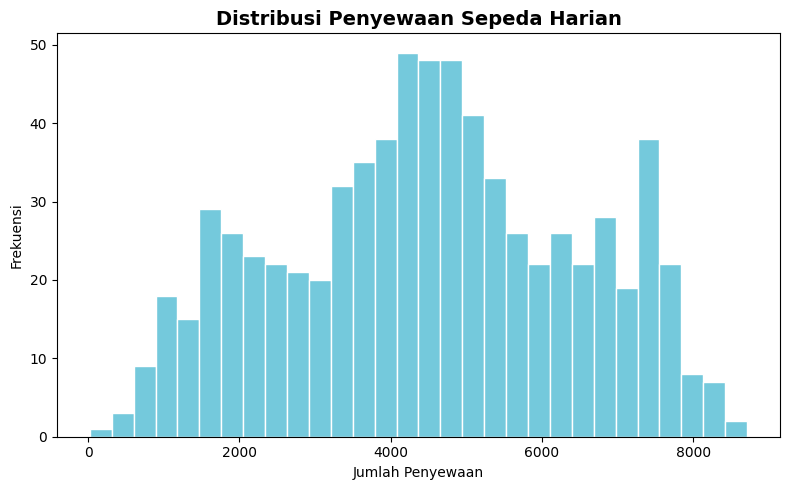

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(day_df['cnt'], bins=30, color='#45B7D1', edgecolor='white')
plt.title("Distribusi Penyewaan Sepeda Harian", fontsize=14, fontweight='bold')
plt.xlabel("Jumlah Penyewaan")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

### Explore Data Per Jam

In [20]:
hour_df.groupby('hr')['cnt'].describe()

,count,mean,std,min,25%,50%,75%,max
hr,,,,,,,,
0,726.0,53.898072,42.307910,2.0,25.00,40.0,69.00,283.0
1,724.0,33.375691,33.538727,1.0,11.00,20.0,42.25,168.0
2,715.0,22.869930,26.578642,1.0,5.00,11.0,28.50,132.0
3,697.0,11.727403,13.239190,1.0,3.00,6.0,15.00,79.0
4,697.0,6.352941,4.143818,1.0,3.00,6.0,8.00,28.0
5,717.0,19.889819,13.200765,1.0,8.00,19.0,29.00,66.0
6,725.0,76.044138,55.084348,1.0,23.00,76.0,117.00,213.0
7,727.0,212.064649,161.441936,1.0,55.50,208.0,332.00,596.0
8,727.0,359.011004,235.189285,5.0,131.50,385.0,559.50,839.0


In [21]:
hour_df.groupby('workingday')['cnt'].describe()

,count,mean,std,min,25%,50%,75%,max
workingday,,,,,,,,
0,5514.0,181.405332,172.853832,1.0,40.0,119.0,292.0,783.0
1,11865.0,193.207754,185.107477,1.0,40.0,151.0,277.0,977.0


**Insight:**
- Distribusi jumlah penyewaan sepeda terlihat cukup bervariasi, dengan mayoritas angkanya terpusat pada kisaran menengah hingga tinggi.
- Faktor cuaca memberikan pengaruh yang sangat jelas: rata-rata penyewaan mencapai puncaknya saat cuaca cerah dibandingkan dengan kondisi berkabut atau hujan ringan.
- Berdasarkan data per jam, penyewaan pada hari kerja (workingday=1) memiliki pola yang berbeda dari hari libur (workingday=0).
- Rata-rata penyewaan per jam pada hari kerja menunjukkan standar deviasi yang lebih tinggi, mengindikasikan fluktuasi jam sibuk vs jam sepi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
#### Bagaimana perbandingan jumlah penyewaan sepeda antar musim pada tahun 2012?

C:\Users\Zeleo\AppData\Local\Temp\ipykernel_10228\3826449050.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='season', y='cnt', data=season_df, palette=colors)


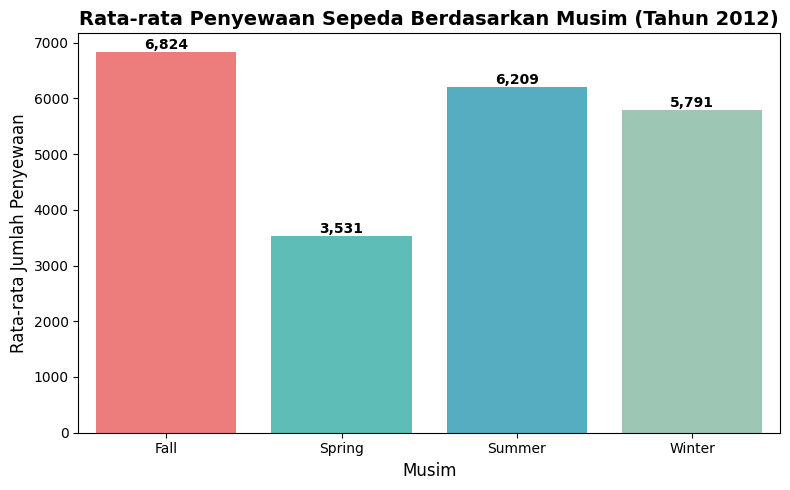

In [22]:
# Filter data tahun 2012 (yr=1 dalam dataset)
day_2012 = day_df[day_df['yr'] == 1]

season_df = day_2012.groupby('season')['cnt'].mean().reset_index()

plt.figure(figsize=(8, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = sns.barplot(x='season', y='cnt', data=season_df, palette=colors)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Musim (Tahun 2012)", fontsize=14, fontweight='bold')
plt.xlabel("Musim", fontsize=12)
plt.ylabel("Rata-rata Jumlah Penyewaan", fontsize=12)

for bar in bars.patches:
    bars.annotate(f'{int(bar.get_height()):,}',
                  (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                  ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
Musim gugur (Fall) menunjukkan rata-rata penyewaan sepeda tertinggi pada tahun 2012, sedangkan musim semi (Spring) memiliki rata-rata paling rendah.

**Interpretasi:**
Kondisi cuaca yang nyaman pada musim gugur mendorong lebih banyak orang untuk menggunakan sepeda, sementara suhu dingin dan cuaca tidak stabil di musim semi mengurangi minat pengguna.

**Implikasi:**
Operator perlu menyesuaikan ketersediaan armada sepeda berdasarkan musim—meningkatkan supply di musim gugur dan memberikan insentif di musim semi.

### Pertanyaan 2:
#### Sejauh mana kondisi cuaca memengaruhi jumlah penyewaan sepeda harian selama tahun 2012?

C:\Users\Zeleo\AppData\Local\Temp\ipykernel_10228\799498373.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='weathersit', y='cnt', data=weather_df, palette=colors_w[:len(weather_df)])


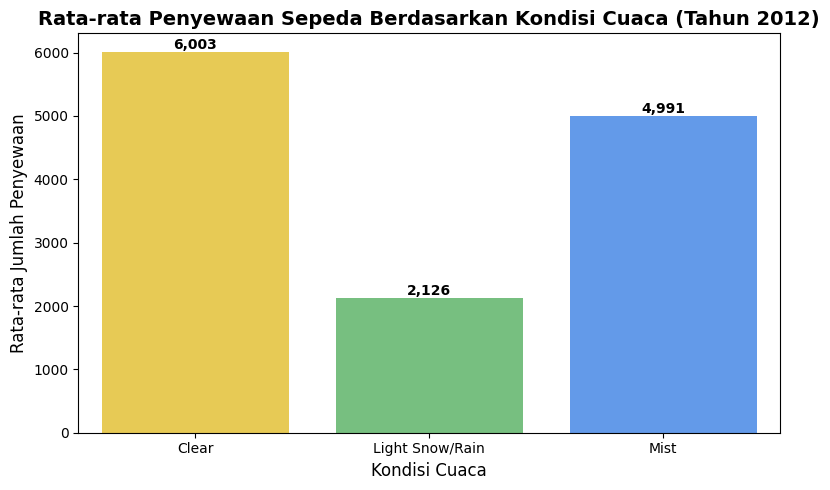

In [23]:
weather_df = day_2012.groupby('weathersit')['cnt'].mean().reset_index()

plt.figure(figsize=(8, 5))
colors_w = ['#FFD93D', '#6BCB77', '#4D96FF']
bars = sns.barplot(x='weathersit', y='cnt', data=weather_df, palette=colors_w[:len(weather_df)])

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca (Tahun 2012)", fontsize=14, fontweight='bold')
plt.xlabel("Kondisi Cuaca", fontsize=12)
plt.ylabel("Rata-rata Jumlah Penyewaan", fontsize=12)

for bar in bars.patches:
    bars.annotate(f'{int(bar.get_height()):,}',
                  (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                  ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
Cuaca cerah (Clear) menghasilkan rata-rata penyewaan tertinggi selama tahun 2012, sedangkan kondisi cuaca buruk (Light Snow/Rain) menyebabkan penurunan signifikan.

**Interpretasi:**
Kondisi cuaca memiliki pengaruh besar terhadap keputusan pengguna dalam menyewa sepeda. Cuaca berkabut (Mist) masih cukup tinggi, menunjukkan bahwa pengguna tetap toleran terhadap cuaca mendung.

**Implikasi:**
Disarankan untuk mengintegrasikan data prakiraan cuaca ke dalam sistem operasional guna memprediksi demand harian dan mengoptimalkan distribusi sepeda.

### Pertanyaan 3:
#### Bagaimana perbandingan tren jam sibuk penyewaan sepeda antara hari kerja dan hari libur dalam 12 bulan terakhir?

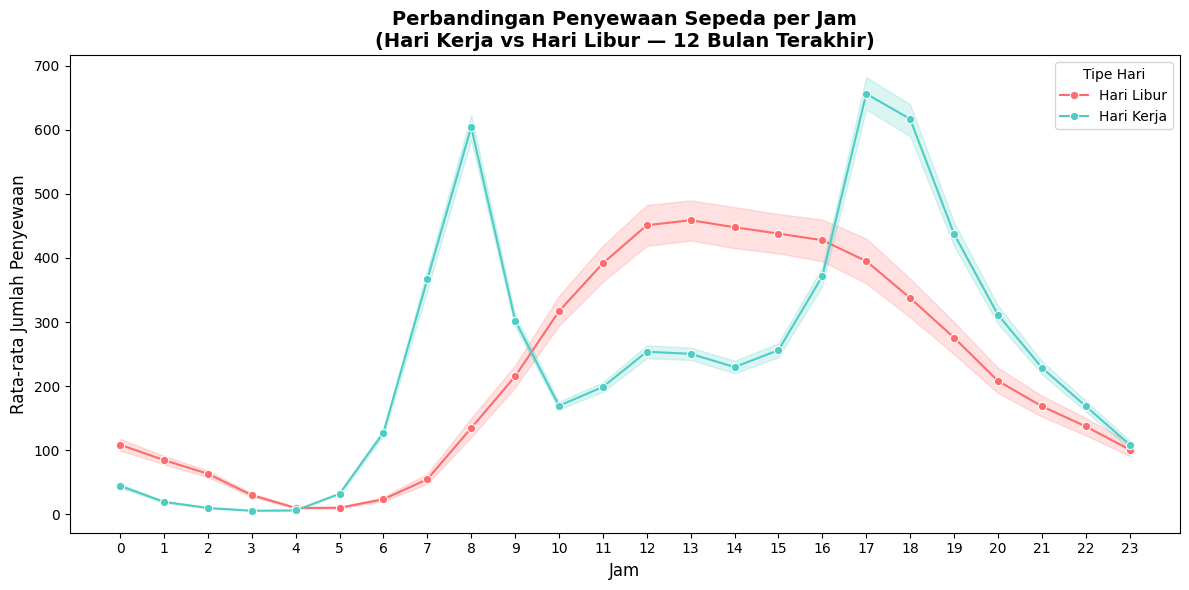

In [24]:
# Filter 12 bulan terakhir (tahun 2012 = yr==1)
hour_2012 = hour_df[hour_df['yr'] == 1].copy()
hour_2012['workingday_label'] = hour_2012['workingday'].map({0: 'Hari Libur', 1: 'Hari Kerja'})

plt.figure(figsize=(12, 6))
sns.lineplot(data=hour_2012, x='hr', y='cnt', hue='workingday_label',
             marker='o', palette=['#FF6B6B', '#4ECDC4'])

plt.title("Perbandingan Penyewaan Sepeda per Jam\n(Hari Kerja vs Hari Libur — 12 Bulan Terakhir)",
          fontsize=14, fontweight='bold')
plt.xlabel("Jam", fontsize=12)
plt.ylabel("Rata-rata Jumlah Penyewaan", fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title='Tipe Hari', fontsize=10)
plt.tight_layout()
plt.show()

**Insight:**
- Pada **hari kerja**, terdapat dua puncak utama penyewaan: pagi hari sekitar pukul 08.00 dan sore hari sekitar pukul 17.00–18.00.
- Pada **hari libur**, pola penyewaan lebih merata dengan puncak di siang hari sekitar pukul 11.00–15.00.

**Interpretasi:**
Pola hari kerja menunjukkan penggunaan sepeda didominasi oleh aktivitas commuting (berangkat dan pulang kerja), sementara hari libur menunjukkan pola rekreasi.

**Implikasi:**
- Perlu dilakukan penambahan unit sepeda pada jam commuting (08.00 & 17.00) selama hari kerja untuk memenuhi demand.
- Pada hari libur, redistribusi sepeda ke area rekreasi perlu dilakukan lebih awal.
- Jadwal maintenance sebaiknya disesuaikan di luar jam sibuk.

## Analisis Lanjutan

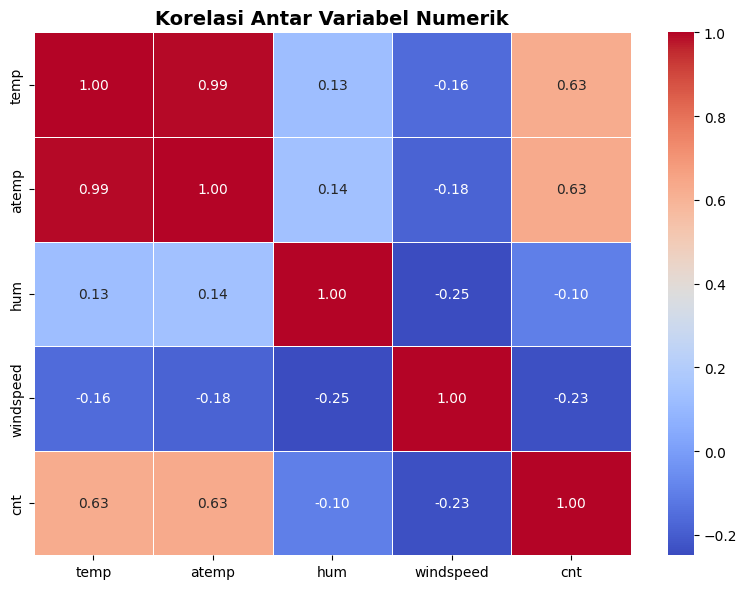

In [25]:
# Korelasi antara variabel numerik
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']

plt.figure(figsize=(8, 6))
sns.heatmap(day_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Korelasi Antar Variabel Numerik", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- Temperatur (`temp`) dan temperatur yang dirasakan (`atemp`) memiliki korelasi positif yang kuat terhadap jumlah penyewaan sepeda.
- Kelembapan (`hum`) menunjukkan korelasi negatif yang moderat, artinya kelembapan tinggi cenderung mengurangi penyewaan.
- Kecepatan angin (`windspeed`) memiliki korelasi negatif yang lemah terhadap penyewaan.

**Interpretasi:**
Faktor suhu menjadi pendorong utama penyewaan sepeda. Semakin nyaman suhu, semakin tinggi penggunaan.

**Implikasi:**
Data temperatur dapat digunakan sebagai prediktor demand dalam sistem forecasting operasional.

C:\Users\Zeleo\AppData\Local\Temp\ipykernel_10228\4086376063.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cnt_group', data=day_df, palette='Set2', order=labels)


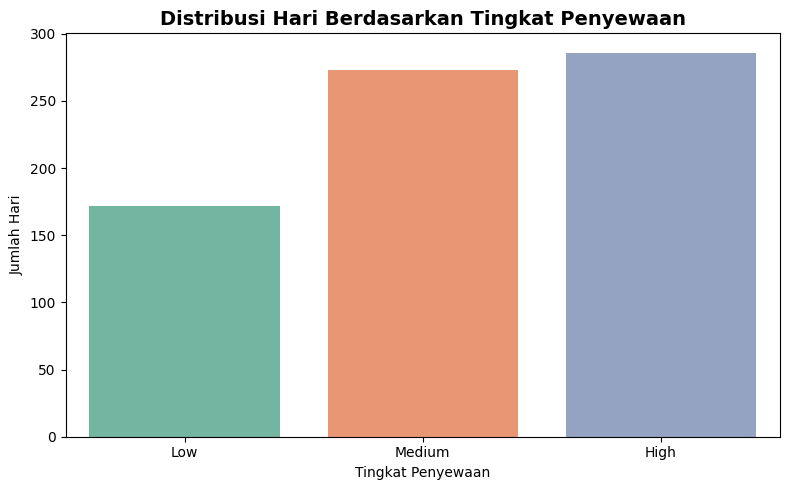

In [26]:
# Pengelompokan berdasarkan tingkat penyewaan
bins = [0, 3000, 5000, 9000]
labels = ['Low', 'Medium', 'High']
day_df['cnt_group'] = pd.cut(day_df['cnt'], bins=bins, labels=labels)

plt.figure(figsize=(8, 5))
sns.countplot(x='cnt_group', data=day_df, palette='Set2', order=labels)
plt.title("Distribusi Hari Berdasarkan Tingkat Penyewaan", fontsize=14, fontweight='bold')
plt.xlabel("Tingkat Penyewaan")
plt.ylabel("Jumlah Hari")
plt.tight_layout()
plt.show()

## Conclusion

### Kesimpulan Pertanyaan 1
**Bagaimana perbandingan jumlah penyewaan sepeda antar musim pada tahun 2012?**

**Kesimpulan:**
Musim memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda. Musim gugur (Fall) menunjukkan rata-rata penyewaan tertinggi pada tahun 2012, sedangkan musim semi (Spring) memiliki tingkat penyewaan paling rendah.

**Rekomendasi:**
- **Disarankan** untuk meningkatkan ketersediaan armada sepeda selama musim gugur guna memenuhi demand yang tinggi.
- **Perlu dilakukan** strategi promosi khusus (misalnya paket diskon atau event) selama musim semi untuk mendorong penyewaan.
- **Strategi yang dapat diterapkan:** perencanaan jadwal maintenance preventif di musim sepi (Spring) agar armada siap optimal di musim ramai.

### Kesimpulan Pertanyaan 2
**Sejauh mana kondisi cuaca memengaruhi jumlah penyewaan sepeda harian selama tahun 2012?**

**Kesimpulan:**
Kondisi cuaca berperan sangat penting dalam memengaruhi jumlah penyewaan. Cuaca cerah (Clear) menghasilkan jumlah penyewaan tertinggi, sementara kondisi cuaca buruk seperti hujan atau salju menyebabkan penurunan yang signifikan.

**Rekomendasi:**
- **Disarankan** untuk mengintegrasikan data prakiraan cuaca ke dalam sistem operasional untuk memprediksi fluktuasi demand harian.
- **Perlu dilakukan** pengurangan unit aktif saat cuaca buruk untuk efisiensi biaya pemeliharaan.
- **Strategi yang dapat diterapkan:** menawarkan insentif atau program indoor activity saat cuaca buruk untuk menjaga engagement pelanggan.

### Kesimpulan Pertanyaan 3
**Bagaimana perbandingan tren jam sibuk penyewaan sepeda antara hari kerja dan hari libur dalam 12 bulan terakhir?**

**Kesimpulan:**
Pola penyewaan berdasarkan waktu menunjukkan perbedaan signifikan antara hari kerja dan hari libur:
- **Hari kerja:** dua puncak utama (pagi jam 08.00 dan sore jam 17.00–18.00) menunjukkan pola commuting.
- **Hari libur:** pola lebih merata dengan puncak di siang hari (11.00–15.00) menunjukkan pola rekreasi.

**Rekomendasi:**
- **Disarankan** untuk meningkatkan ketersediaan sepeda pada jam commuting (08.00 & 17.00) selama hari kerja guna mengoptimalkan operasional.
- **Perlu dilakukan** redistribusi sepeda lebih awal pada hari libur ke area rekreasi dan taman kota.
- **Strategi yang dapat diterapkan:** penyesuaian jadwal maintenance di luar jam sibuk dan dynamic pricing berdasarkan jam untuk mengoptimalkan revenue.

#### SIMPAN DATA UNTUK DASHBOARD

In [27]:
day_df.to_csv('dashboard/main_data.csv', index=False)
print("Data berhasil disimpan ke dashboard/main_data.csv")

Data berhasil disimpan ke dashboard/main_data.csv


In [28]:
pd.read_csv('dashboard/main_data.csv').head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,cnt_group
0,1,2011-01-01,Spring,0,1,0,6,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985,Low
1,2,2011-01-02,Spring,0,1,0,0,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801,Low
2,3,2011-01-03,Spring,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Low
3,4,2011-01-04,Spring,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Low
4,5,2011-01-05,Spring,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Low
